# Linear Regression

Linear regression is a very straightforward approach for predicting a quantitative response Y on the basis of predictor variables X's. The model comes in the form of:<br>
$\hat{y} = w1.x1 + w2.x2 + ... + b$ <br><br>

It uses MSE loss to maximize the likelihood function:<br>
$L = \frac{1}{2n} . \sum_i{(y_i-\hat{y}_i)^2}$ <br><br>

Then we minimize MSE by using gradient of loss w.r.t w and b to find optimal w and b:<br>
$min_{w,b}L$

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import f_regression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [68]:
df = pd.read_csv("data/Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [70]:
cat_feats = []
num_feats = []
target = 'Performance Index'

for col, dtype in dict(df.dtypes).items():
    if dtype in [np.int64, np.float64] and not col == target:
        num_feats.append(col)
    elif dtype == np.dtypes.ObjectDType:
        cat_feats.append(col)

print(cat_feats)
print(num_feats)

['Extracurricular Activities']
['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']


<Axes: xlabel='Extracurricular Activities', ylabel='Performance Index'>

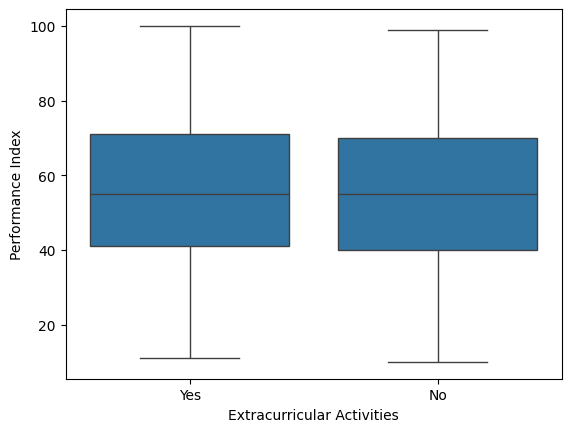

In [71]:
sns.boxplot(x=cat_feats[0], y=target, data=df)

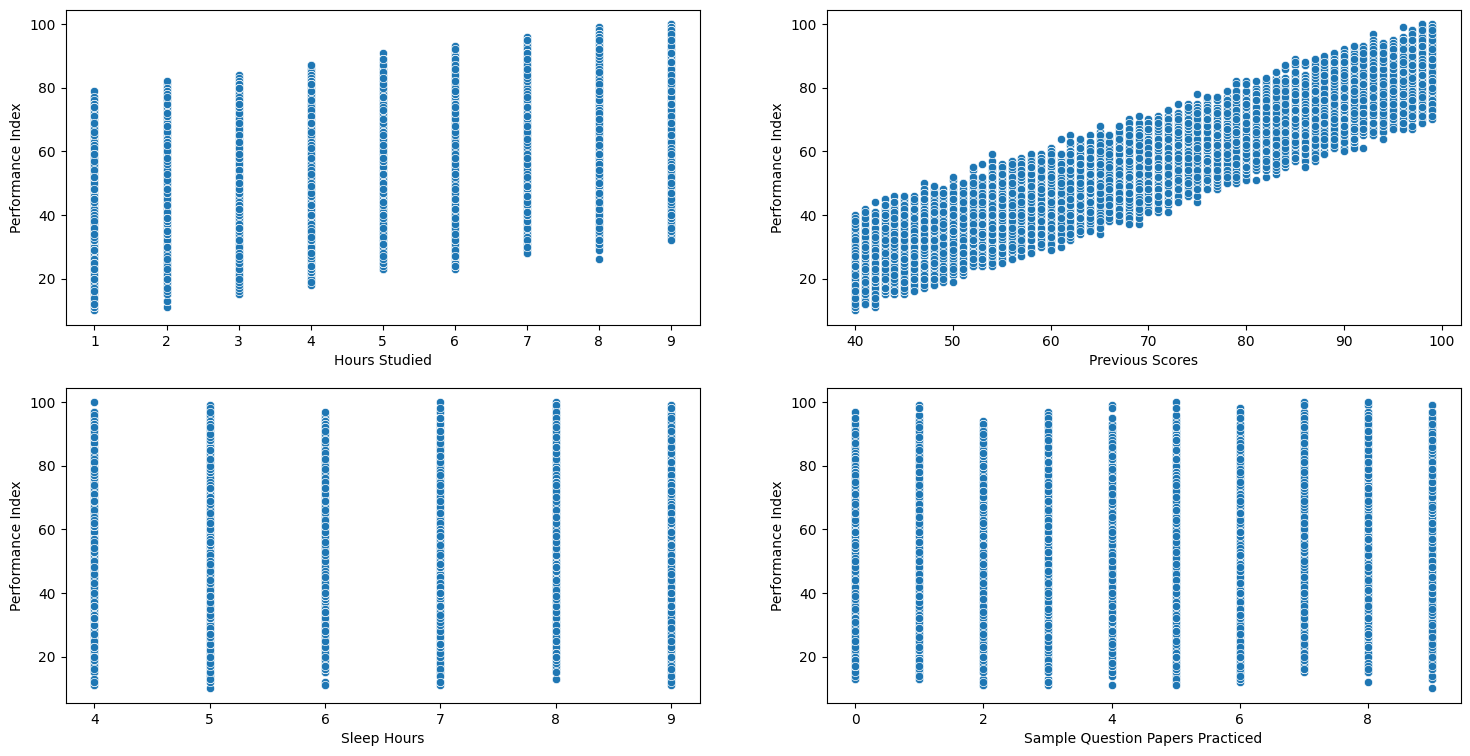

In [72]:
fig, axes = plt.subplots(nrows=2, ncols=2, sharex=False, figsize=(18, 9))

for i, col in enumerate(num_feats):
    r = i//2
    c = i%2
    ax = axes[r][c]
    sns.scatterplot(x=col, y=target, data=df, ax=ax)

In [74]:
def get_rse(mse, n, p):
    df = n - p - 1
    rse = np.sqrt(mse * (n / df))
    return rse

In [75]:
train_features = cat_feats + num_feats

for cf in cat_feats:
    cats = list(df[cf].unique())
    cats.sort()
    encoder = OrdinalEncoder(categories=[cats])
    df[cf] = encoder.fit_transform(df[[cf]]).astype(int)
    
X = df[train_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(7000, 5) (7000,)
(3000, 5) (3000,)


In [ ]:
reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred = reg.predict(X_train)
train_mse = mean_squared_error(y_train, y_pred)
train_r2 = r2_score(y_train, y_pred)
train_rse = get_rse(train_mse, len(y_train), X_train.shape[-1])

print(f"train mse: {train_mse}")
print(f"train r2: {train_r2}")
print(f"train rse: {train_rse}")

y_pred = reg.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)
test_rse = get_rse(test_mse, len(y_test), X_test.shape[-1])

print(f"test mse: {test_mse}")
print(f"test r2: {test_r2}")
print(f"test rse: {test_rse}")

train mse: 4.193473712437295
train r2: 0.9886221887978632
train rse: 2.0486754750421166
test mse: 4.066563824092678
test r2: 0.9890110607021136
test rse: 2.018591897980834


After fitting regression model, let's see which predictor has the most influence over response variable.

In [57]:
f_statistics, p_values = f_regression(X_train, y_train)

In [58]:
pd.DataFrame([f_statistics], columns=train_features).head()

,Extracurricular Activities,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced
0,3.449539,1173.472236,35610.645653,17.051172,12.112566


According to F-statistics, we can see that 'Previous Scores' have largest F-statistics score, meaning it has the most influence over the response variable. 'Hours Studied' followed second with 1173.47. 'Extracurricular Activities' is the least influential among all the predictors with smallest F-statistics score.

In [59]:
pd.DataFrame([p_values], columns=train_features).head()

,Extracurricular Activities,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced
0,0.063311,6.691276e-238,0.0,0.000037,0.000504


Similarly, p-value of 'Previous Scores' and 'Hours Studied' show significance with less than 0 scores. 
'Extracurricular Activities' shows largest p-value here meaning least influential of all.